# Lung Sound Classification (HLS-CMDS)

Classifies **lung sound type** (Normal, Wheezing, Rhonchi, Coarse/Fine Crackles, Pleural Rub) from the [HLS-CMDS](https://doi.org/10.1109/IEEEDATA.2025.3566012) recordings, using an MLP trained on pooled log-mel spectrogram features.

## Setup

Imports: `pathlib` for file globbing, `pandas` to read the label CSVs, `librosa`/`numpy` for audio loading and feature extraction, `sklearn` for the train/test split and evaluation metrics, and `torch` for the MLP and training loop.

In [2]:
from pathlib import Path
import numpy as np, pandas as pd, librosa, torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## Configuration

`ROOT` points at the `HLS-CMDS/` dataset folder (see `README.md` for the download/layout instructions — it's gitignored because of the `.wav` files). Audio is resampled to `SAMPLE_RATE=8000` Hz and every clip is fixed to `SECS=6.0` s so all spectrograms come out the same shape; `N_MELS`/`N_FFT`/`HOP` control the mel-spectrogram resolution.

In [3]:
ROOT = Path("HLS-CMDS")
SAMPLE_RATE = 8000
HOP_LENGTH = 256
SECS = 10.0
N_MELS = 64
LENGTH_OF_FFT = 1024
RANDOM_STATE = 42

## Build the file index

Lung-labeled recordings come from two places: `LS/LS/*.wav` and the `L####.wav` files inside `Mix/Mix/` (the isolated lung component of each mixed recording, labeled by `Mix.csv`'s `Lung Sound ID`/`Lung Sound Type` columns, e.g. `L0001.wav`). Combining both sources gives 195 samples across 6 balanced classes instead of just the 50 in `LS.csv` alone.

Note: `LS.csv`'s own `Lung Sound ID` column doesn't reliably match the real filenames — it abbreviates Coarse Crackles as `G` and Fine Crackles as `C` (e.g. `M_G_LLA`), while the actual `.wav` files on disk use `CC`/`FC` (e.g. `M_CC_LLA.wav`). So for `LS/LS/` we decode the label directly from the filename's own code via a fixed `CODE2TYPE` table instead of joining on that ID column; `Mix.csv`'s numeric IDs (`L0001`, ...) don't have this problem and are looked up normally.

`CLASSES` is the sorted set of the 6 lung sound types, and `LABEL2IDX` maps each type name to the integer index used for training.

In [4]:
CODE2TYPE = {
    "N": "Normal", 
    "CC": "Coarse Crackles", 
    "FC": "Fine Crackles",
    "R": "Rhonchi", 
    "W": "Wheezing", 
    "PR": "Pleural Rub"
    }
mix_type = pd.read_csv(ROOT/"Mix.csv").set_index("Lung Sound ID")["Lung Sound Type"]

CLASSES = sorted(CODE2TYPE.values())
LABEL2IDX = {c: i for i, c in enumerate(CLASSES)}

def build_index():
    recs = [(wav, LABEL2IDX[CODE2TYPE[wav.stem.split("_")[1]]]) for wav in (ROOT/"LS"/"LS").glob("*.wav")]
    recs += [(wav, LABEL2IDX[mix_type[wav.stem]]) for wav in (ROOT/"Mix"/"Mix").glob("L*.wav")]
    return recs

## Feature extraction

`to_melspec` turns a `.wav` file into a normalized log-mel spectrogram:

1. Load audio mono at `SAMPLE_RATE` and center-crop or zero-pad it to exactly `SECS` seconds, so every clip yields a fixed-size input.
2. Compute a mel-spectrogram and convert power to decibels (`power_to_db`).
3. Standardize (zero mean, unit variance) so all clips are on a comparable scale.

An MLP takes a flat feature vector, not a 2-D image like a CNN would, and with only 195 samples a `64 x 188` spectrogram (12,032 values) would badly overfit. `to_features` pools the spectrogram over time — mean and std per mel band — collapsing it to a fixed `2 * N_MELS = 128`-dim vector that summarizes each clip's frequency content.

In [5]:
def to_melspec(path):
    y, _ = librosa.load(path, sr=SAMPLE_RATE, mono=True)
    n = int(SECS*SAMPLE_RATE)
    y = np.pad(y, (0, n-len(y))) if len(y) < n else y[(len(y)-n)//2:(len(y)-n)//2+n]
    mel = librosa.feature.melspectrogram(y=y, sr=SAMPLE_RATE, n_fft=LENGTH_OF_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
    m = librosa.power_to_db(mel, ref=np.max)
    return ((m - m.mean()) / (m.std() + 1e-6)).astype(np.float32)

def to_features(path):
    spec = to_melspec(path)
    return np.concatenate([spec.mean(axis=1), spec.std(axis=1)]).astype(np.float32)

## Dataset

Thin `torch.utils.data.Dataset` wrapper: given a list of `(path, label)` pairs (from `build_index`), it lazily computes the pooled feature vector per item and returns it as a `(128,)` float tensor plus its integer class label, ready for a `DataLoader`/MLP.

In [6]:
class LungSounds(Dataset):
    def __init__(self, recs):
        self.recs = recs
    def __len__(self): return len(self.recs)
    def __getitem__(self, i):
        path, label = self.recs[i]
        return torch.from_numpy(to_features(path)), label

In [7]:
from collections import Counter
recs = build_index()
print(Counter(CLASSES[l] for _, l in recs))
print("feature shape:", to_features(recs[0][0]).shape)

Counter({'Normal': 40, 'Wheezing': 35, 'Pleural Rub': 34, 'Rhonchi': 31, 'Coarse Crackles': 28, 'Fine Crackles': 27})
feature shape: (128,)


## Removing duplicate recordings

`Mix/Mix/L####.wav` isolates the lung component out of each heart+lung mixture, but the same lung recording gets reused across several different heart-sound pairings — and 45 of those isolated components are byte-for-byte identical to a file that also lives in `LS/LS/` (verified directly on the waveforms: `corrcoef` = 1.0, zero max absolute difference, not just a metadata coincidence). So the 195 `.wav` files reduce to only 94 acoustically unique lung sounds.

The deduplicated `.wav` files and their labels are also copied out to `HLS-CMDS/Unique/` and `HLS-CMDS/unique_lung_sounds.csv`, so group mates can work from the clean 94-clip set directly instead of re-running the hashing step themselves.

In [8]:
import hashlib, shutil

def audio_group_id(path):
    return hashlib.md5(Path(path).read_bytes()).hexdigest()

seen, deduped = set(), []
for path, label in recs:
    gid = audio_group_id(path)
    if gid not in seen:
        seen.add(gid)
        deduped.append((path, label))

print(f"{len(recs)} recordings -> {len(deduped)} acoustically unique "
      f"({len(recs) - len(deduped)} duplicates dropped)")
recs = deduped

UNIQUE_DIR = ROOT/"Unique"
UNIQUE_DIR.mkdir(exist_ok=True)
for path, _ in recs:
    shutil.copy2(path, UNIQUE_DIR/path.name)

unique_df = pd.DataFrame(
    [{"filename": path.name, "label": CLASSES[label]} for path, label in recs]
)
unique_df.to_csv(ROOT/"unique_lung_sounds.csv", index=False)
print(f"Saved {len(unique_df)} deduplicated clips to {UNIQUE_DIR}/ "
      f"and labels to {ROOT/'unique_lung_sounds.csv'}")

195 recordings -> 94 acoustically unique (101 duplicates dropped)
Saved 94 deduplicated clips to HLS-CMDS/Unique/ and labels to HLS-CMDS/unique_lung_sounds.csv


## Multi-Layer Perceptron (scikit-learn)

Split `(features, label)` with a stratified `train_test_split`, holding out 20% as the test set. Tune an `MLPClassifier` with `GridSearchCV`, using `StratifiedKFold` as its `cv`. The classifier is wrapped in a `Pipeline` with a `StandardScaler` so feature scaling is refit on each fold's training data only. The grid searches over hidden layer size, activation, L2 penalty (`alpha`), and initial learning rate.

In [9]:
X = np.stack([to_features(path) for path, _ in recs])
y = np.array([label for _, label in recs])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=2000, early_stopping=False, random_state=RANDOM_STATE)),
])

param_grid = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (64, 32)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": [1e-4, 1e-3, 1e-2],
    "mlp__learning_rate_init": [1e-3, 1e-2],
}

grid_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(pipe, param_grid, cv=grid_cv, scoring="accuracy", n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV accuracy: %.3f" % grid.best_score_)

Best params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.0001, 'mlp__hidden_layer_sizes': (64, 32), 'mlp__learning_rate_init': 0.001}
Best CV accuracy: 0.920


## Evaluation

Refit on the full training split happens automatically inside `GridSearchCV` (`refit=True` by default), so `grid.best_estimator_` is ready to score on the held-out test set. Report per-class precision/recall/F1 and the confusion matrix — then, since one 80/20 split is a noisy estimate on a dataset this small, also run 5-fold cross-validation with the tuned hyperparameters over the *entire* dataset and report the average (mean ± std) accuracy across folds.

                 precision    recall  f1-score   support

Coarse Crackles       1.00      1.00      1.00         3
  Fine Crackles       1.00      0.67      0.80         3
         Normal       0.75      1.00      0.86         3
    Pleural Rub       0.80      1.00      0.89         4
        Rhonchi       1.00      0.33      0.50         3
       Wheezing       0.75      1.00      0.86         3

       accuracy                           0.84        19
      macro avg       0.88      0.83      0.82        19
   weighted avg       0.88      0.84      0.82        19



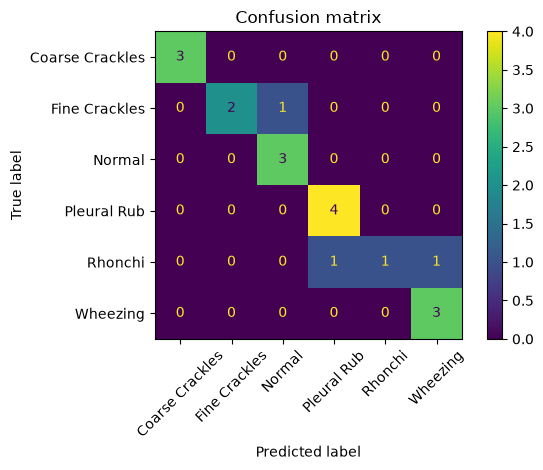

In [10]:
best_mlp = grid.best_estimator_
y_pred = best_mlp.predict(X_test)

print(classification_report(y_test, y_pred, target_names=CLASSES))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=CLASSES, xticks_rotation=45)
plt.title("Confusion matrix")
plt.tight_layout()
plt.show()

In [11]:
cv_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(max_iter=2000, early_stopping=False, random_state=RANDOM_STATE).set_params(
        **{k.split("__", 1)[1]: v for k, v in grid.best_params_.items()}
    )),
])

eval_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(cv_pipe, X, y, cv=eval_cv, scoring="accuracy", n_jobs=-1)

print("Per-fold accuracy:", np.round(cv_scores, 3))
print(f"Average cross-validated accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

Per-fold accuracy: [0.947 0.842 0.842 0.842 0.944]
Average cross-validated accuracy: 0.884 ± 0.051
